# rdf-augmenter - Visualizing Augmentation

Every figure below is generated from a **real** augmentation run - nothing is hard-coded. We visualise graph growth, the predicate and degree distributions, and the augmented graph itself.

In [1]:
%matplotlib inline
# Make the package importable whether you pip-installed rdf-augmenter
# or are running these notebooks straight from the cloned repository.
import sys, pathlib
try:
    import rdf_augmenter  # noqa: F401
except ModuleNotFoundError:
    repo = pathlib.Path.cwd().parent
    sys.path.insert(0, str(repo))
    import rdf_augmenter  # noqa: F401
print('rdf-augmenter', rdf_augmenter.__version__)


rdf-augmenter 0.2.0


In [2]:
import pathlib
SAMPLE = next(p for p in [pathlib.Path('../examples/sample_people.ttl'),
                          pathlib.Path('examples/sample_people.ttl')] if p.exists())
from rdflib import Graph
from rdf_augmenter import RDFAugmenter, viz

original = Graph(); original.parse(str(SAMPLE), format='turtle')
aug = RDFAugmenter(seed=42); aug.load(str(SAMPLE))
report = aug.augment(predicates=['http://example.org/occupation'], top_k=4, provenance=False)
print(report.summary())


RDF augmentation report
-----------------------
backend            : lexicon
seed               : 42
triples before     : 16
triples after      : 94
triples added      : 78
  - hypernym      : 24
  - related       : 32
  - synonym       : 22


## Graph growth: before vs. after

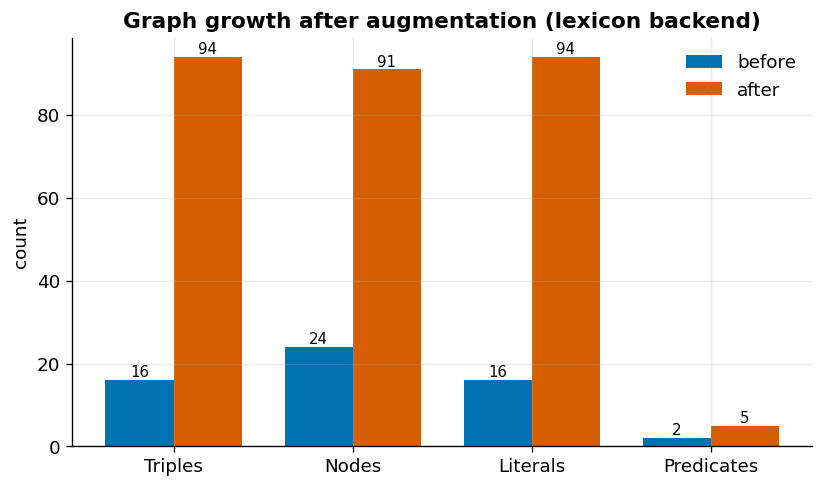

In [3]:
viz.plot_growth(report);

## Predicate distribution

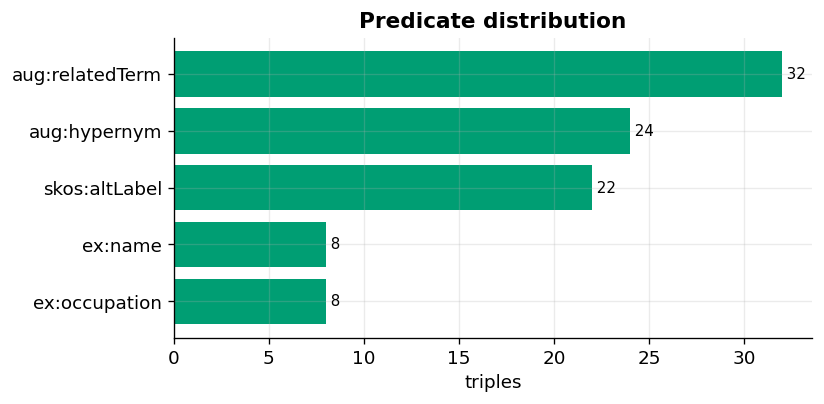

In [4]:
viz.plot_predicate_distribution(aug.graph);

## Degree distribution (topology)

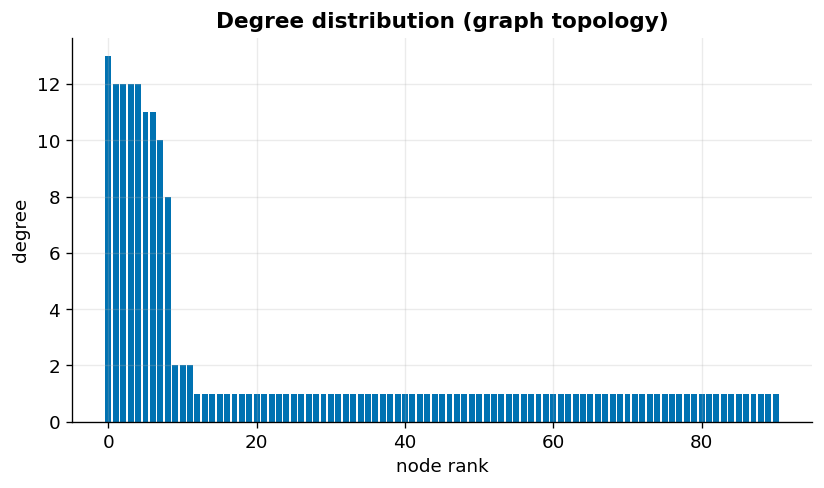

In [5]:
viz.plot_degree_distribution(aug.graph);

## The augmented graph

Blue nodes existed in the original graph; orange nodes were added by augmentation.

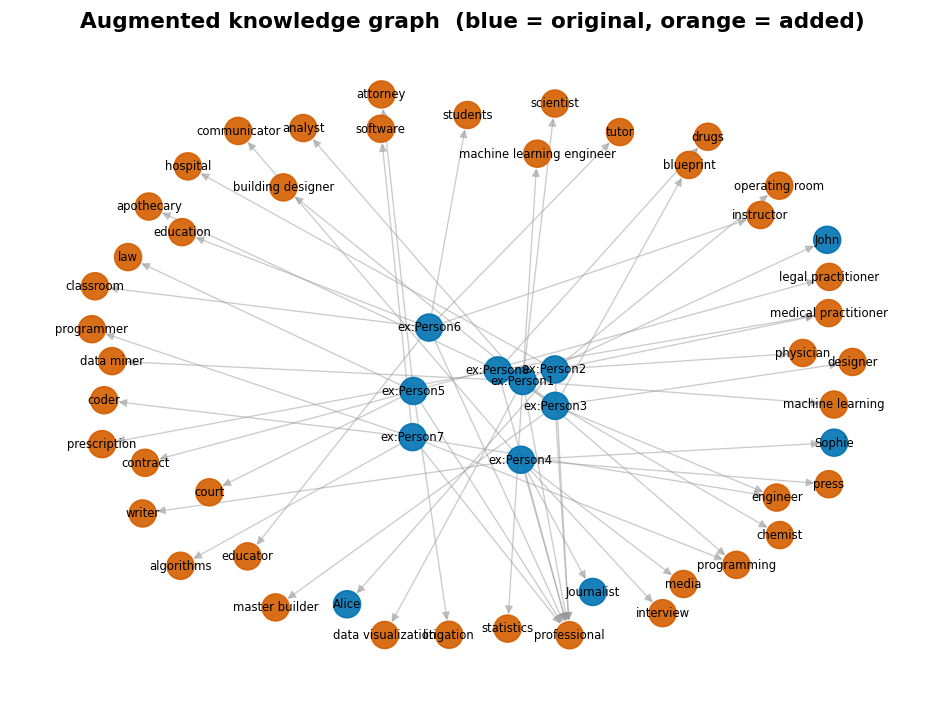

In [6]:
viz.draw_graph(aug.graph, original=original, max_nodes=55);

## How much does `top_k` change the result?

A genuine parameter sweep - we re-run augmentation for several `top_k` values.

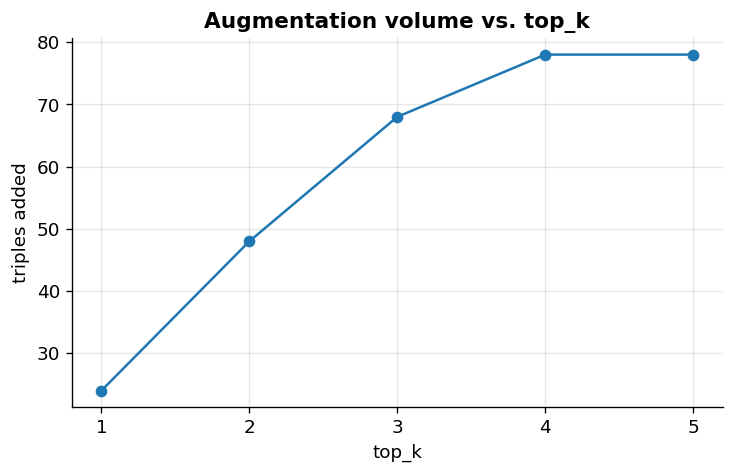

In [7]:
import matplotlib.pyplot as plt
ks, added = [1,2,3,4,5], []
for k in ks:
    a = RDFAugmenter(seed=42); a.load(str(SAMPLE))
    added.append(a.augment(predicates=['http://example.org/occupation'], top_k=k, provenance=False).added)
plt.figure(figsize=(7,4))
plt.plot(ks, added, marker='o')
plt.xlabel('top_k'); plt.ylabel('triples added'); plt.title('Augmentation volume vs. top_k')
plt.xticks(ks); plt.grid(alpha=.3); plt.show()


## Bonus: build a SKOS thesaurus (`attach='concept'`)

Instead of attaching literals to people, concept mode mints a `skos:Concept` per occupation and links synonyms (`skos:altLabel`), hypernyms (`skos:broader`) and related terms (`skos:related`) - a semantically cleaner structure.

In [8]:
thes = RDFAugmenter(seed=42); thes.load(str(SAMPLE))
thes.augment(predicates=['http://example.org/occupation'], attach='concept', top_k=3)
ttl = thes.export(fmt='turtle')
block = [b for b in ttl.split(chr(10)+chr(10)) if 'skos:broader' in b][0]
print(block)


<https://w3id.org/rdf-augmenter/ns#concept/architect> a skos:Concept ;
    skos:altLabel "building designer",
        "master builder" ;
    skos:broader <https://w3id.org/rdf-augmenter/ns#concept/designer>,
        <https://w3id.org/rdf-augmenter/ns#concept/engineer>,
        <https://w3id.org/rdf-augmenter/ns#concept/professional> ;
    skos:prefLabel "Architect" ;
    skos:related <https://w3id.org/rdf-augmenter/ns#concept/architecture>,
        <https://w3id.org/rdf-augmenter/ns#concept/blueprint>,
        <https://w3id.org/rdf-augmenter/ns#concept/construction> .
